In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [49]:
df_wgi = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Extra\WGI_master_panel_final.xlsx")

print(df_wgi.head())


       Country  Year  Control of corruption  Rule of law  \
0  afghanistan  2004                    0.0        0.075   
1  afghanistan  2005                    0.0        0.075   
2  afghanistan  2006                    0.0        0.025   
3  afghanistan  2007                    NaN          NaN   
4  afghanistan  2008                    NaN          NaN   

   Government Effectiveness  Political Stability  Voice and Accountability  \
0                      0.25               0.1875                     0.000   
1                      0.25               0.0625                     0.000   
2                      0.00               0.0625                     0.102   
3                       NaN                  NaN                     0.306   
4                       NaN                  NaN                     0.302   

   Regulatory Quality  Attacks  
0            0.107143     88.0  
1            0.107143    155.0  
2            0.107143    283.0  
3                 NaN    342.0  
4    

In [55]:
df_socio = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Panel Data\Final_Master_Panel_AllColumns.csv")
df_socio = df_socio.groupby(["Country", "Year"], as_index=False).mean(numeric_only=True)
print("Socio shape:", df_socio.shape)
print(df_socio.head())

Socio shape: (10125, 9)
       Country  Year  GDP  Attacks  Total_Population  Poverty_Headcount  \
0  Afghanistan  1970  NaN      NaN        11290128.0                NaN   
1  Afghanistan  1971  NaN      NaN        11567667.0                NaN   
2  Afghanistan  1972  NaN      NaN        11853696.0                NaN   
3  Afghanistan  1973  NaN      1.0        12157999.0                NaN   
4  Afghanistan  1974  NaN      NaN        12469127.0                NaN   

   Secondary_Enrollment  Unemployment_Rate  Inequality_Measure  
0               8.36410                NaN                 NaN  
1               9.37827                NaN                 NaN  
2              10.41424                NaN                 NaN  
3              10.93218                NaN                 NaN  
4              11.09488                NaN                 NaN  


In [56]:
import pandas as pd

# =========================
# 1️⃣ Reset index
# =========================
df_wgi = df_wgi.reset_index(drop=True)
df_socio = df_socio.reset_index(drop=True)

# =========================
# 2️⃣ Standardize column names
# =========================
df_wgi.columns = df_wgi.columns.str.strip().str.lower().str.replace(" ", "_")
df_socio.columns = df_socio.columns.str.strip().str.lower().str.replace(" ", "_")

# =========================
# 3️⃣ Standardize key columns
# =========================
df_wgi["country"] = df_wgi["country"].str.lower().str.strip()
df_socio["country"] = df_socio["country"].str.lower().str.strip()

df_wgi["year"] = pd.to_numeric(df_wgi["year"], errors="coerce")
df_socio["year"] = pd.to_numeric(df_socio["year"], errors="coerce")

# =========================
# 4️⃣ Fix numeric columns
# =========================
df_socio = df_socio.apply(pd.to_numeric, errors="ignore")
df_wgi = df_wgi.apply(pd.to_numeric, errors="ignore")

# =========================
# 5️⃣ Remove duplicates (CRITICAL)
# =========================
df_socio = df_socio.groupby(["country", "year"], as_index=False).mean(numeric_only=True)
df_wgi = df_wgi.groupby(["country", "year"], as_index=False).mean(numeric_only=True)

# =========================
# 6️⃣ Keep only overlapping years
# =========================
common_years = set(df_wgi["year"]).intersection(set(df_socio["year"]))

df_wgi = df_wgi[df_wgi["year"].isin(common_years)]
df_socio = df_socio[df_socio["year"].isin(common_years)]

# =========================
# 7️⃣ Merge (INNER = correct for modeling)
# =========================
df_merged = pd.merge(
    df_socio,
    df_wgi,
    on=["country", "year"],
    how="inner"
)

# =========================
# 8️⃣ Fix duplicate 'attacks'
# =========================
if "attacks_x" in df_merged.columns and "attacks_y" in df_merged.columns:
    df_merged["attacks"] = df_merged["attacks_x"].combine_first(df_merged["attacks_y"])
    df_merged = df_merged.drop(columns=["attacks_x", "attacks_y"])

# =========================
# 9️⃣ Drop rows with too many NaNs
# =========================
df_merged = df_merged.dropna(thresh=int(0.7 * df_merged.shape[1]))

# =========================
# 🔟 Final checks
# =========================
print("Final shape:", df_merged.shape)
print("Duplicate keys:", df_merged.duplicated(["country", "year"]).sum())

print("\nMissing values:\n",
      df_merged.isnull().sum().sort_values(ascending=False).head())

# =========================
# 1️⃣1️⃣ Sort and view
# =========================
df_merged = df_merged.sort_values(["country", "year"])

print(df_merged.head())

Final shape: (2803, 15)
Duplicate keys: 0

Missing values:
 poverty_headcount       1554
unemployment_rate        858
secondary_enrollment     792
attacks                   61
gdp                       50
dtype: int64
       country  year        gdp  total_population  poverty_headcount  \
0  afghanistan  2004   1.414118        23560654.0                NaN   
1  afghanistan  2005  11.229715        24404567.0                NaN   
2  afghanistan  2006   5.357403        25424094.0                NaN   
5  afghanistan  2009  21.390528        27466101.0                NaN   
6  afghanistan  2010  14.362441        28284089.0                NaN   

   secondary_enrollment  unemployment_rate  inequality_measure  \
0              19.21438                NaN              0.4095   
1              20.27351                NaN              0.4095   
2              29.52389                NaN              0.4095   
5              44.29995                NaN              0.3982   
6              50.4

C:\Users\DELL\AppData\Local\Temp\ipykernel_16592\2000429263.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_socio = df_socio.apply(pd.to_numeric, errors="ignore")
C:\Users\DELL\AppData\Local\Temp\ipykernel_16592\2000429263.py:28: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_wgi = df_wgi.apply(pd.to_numeric, errors="ignore")


In [97]:
# =========================
# 📊 1️⃣ Basic Table View
# =========================
print("\n🔹 First 10 rows:")
print(df_merged.head(10))

# =========================
# 📏 2️⃣ Shape of Data
# =========================
print("\n🔹 Shape (rows, columns):")
print(df_merged.shape)

# =========================
# 🧾 3️⃣ Column Names
# =========================
print("\n🔹 Columns:")
print(df_merged.columns.tolist())

# =========================
# 🧠 4️⃣ Data Types
# =========================
print("\n🔹 Data Types:")
print(df_merged.dtypes)

# =========================
# 📉 5️⃣ Summary Statistics
# =========================
print("\n🔹 Summary Statistics:")
print(df_merged.describe())

# =========================
# ❗ 6️⃣ Missing Values
# =========================
print("\n🔹 Missing Values:")
print(df_merged.isnull().sum().sort_values(ascending=False))

(df_merged==0).sum()


🔹 First 10 rows:
        country  year        gdp  total_population  poverty_headcount  \
0   afghanistan  2004   1.414118        23560654.0                NaN   
1   afghanistan  2005  11.229715        24404567.0                NaN   
2   afghanistan  2006   5.357403        25424094.0                NaN   
5   afghanistan  2009  21.390528        27466101.0                NaN   
6   afghanistan  2010  14.362441        28284089.0                NaN   
7   afghanistan  2011   0.426355        29347708.0                NaN   
8   afghanistan  2012  12.752287        30560034.0                NaN   
9   afghanistan  2013   5.600745        31622704.0                NaN   
10  afghanistan  2014   2.724543        32792523.0                NaN   
11  afghanistan  2015   1.451315        33831764.0                NaN   

    secondary_enrollment  unemployment_rate  inequality_measure  \
0              19.214380                NaN              0.4095   
1              20.273510                NaN 

country                        0
year                           0
gdp                            0
total_population               0
poverty_headcount             45
secondary_enrollment           0
unemployment_rate              0
inequality_measure             0
control_of_corruption        506
rule_of_law                    0
government_effectiveness     654
political_stability           42
voice_and_accountability      90
regulatory_quality             0
attacks                     1298
dtype: int64

In [86]:
import pandas as pd
from sklearn.impute import SimpleImputer

# =========================
# 1️⃣ Define variables
# =========================
independent_vars = [
    "gdp",
    "poverty_headcount",
    "secondary_enrollment",
    "unemployment_rate",
    "inequality_measure",
    "control_of_corruption",
    "rule_of_law",
    "government_effectiveness",
    "political_stability",
    "voice_and_accountability",
    "regulatory_quality",
    "total_population"
]

target_var = "attacks"

# =========================
# 2️⃣ Keep only rows where target exists
# =========================
df_model = df_merged[df_merged[target_var].notna()].copy()

# =========================
# 3️⃣ Apply threshold (at least 8/12 variables present)
# =========================
threshold = 8

df_model = df_model[
    df_model[independent_vars].notna().sum(axis=1) >= threshold
]

# =========================
# 4️⃣ Imputation (Median - robust)
# =========================
imputer = SimpleImputer(strategy="median")

df_model[independent_vars] = imputer.fit_transform(df_model[independent_vars])

# =========================
# 5️⃣ Final checks
# =========================
print("Final shape:", df_model.shape)

print("\nMissing values after imputation:")
print(df_model[independent_vars].isnull().sum())

# =========================
# 6️⃣ Preview
# =========================
print(df_model.head())

Final shape: (2726, 15)

Missing values after imputation:
gdp                         0
poverty_headcount           0
secondary_enrollment        0
unemployment_rate           0
inequality_measure          0
control_of_corruption       0
rule_of_law                 0
government_effectiveness    0
political_stability         0
voice_and_accountability    0
regulatory_quality          0
total_population            0
dtype: int64
       country  year        gdp  total_population  poverty_headcount  \
0  afghanistan  2004   1.414118        23560654.0           0.013091   
1  afghanistan  2005  11.229715        24404567.0           0.013091   
2  afghanistan  2006   5.357403        25424094.0           0.013091   
5  afghanistan  2009  21.390528        27466101.0           0.013091   
6  afghanistan  2010  14.362441        28284089.0           0.013091   

   secondary_enrollment  unemployment_rate  inequality_measure  \
0              19.21438              6.331              0.4095   
1   

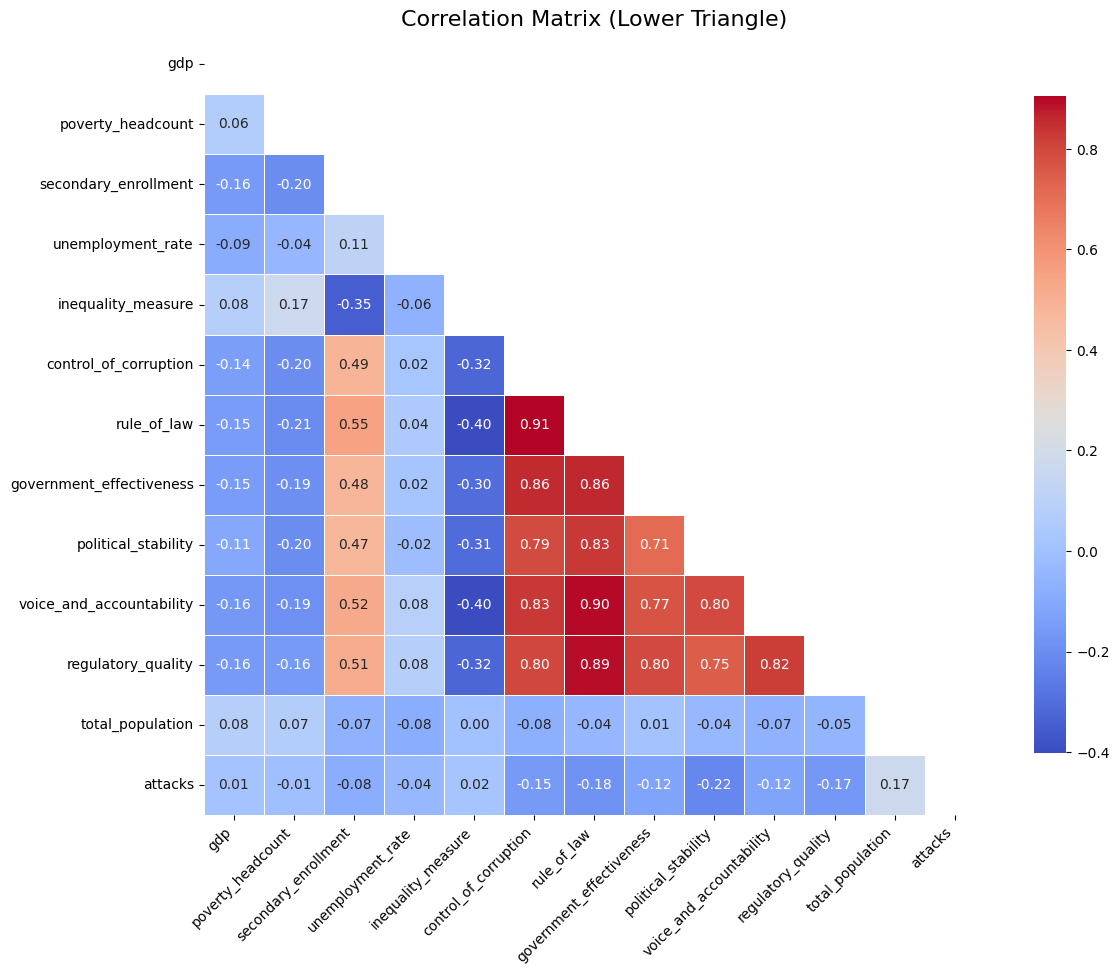

In [87]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Select only relevant numeric variables
df_numeric = df_model[independent_vars + ["attacks"]].copy()

# Correlation matrix
corr = df_numeric.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Lower Triangle)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

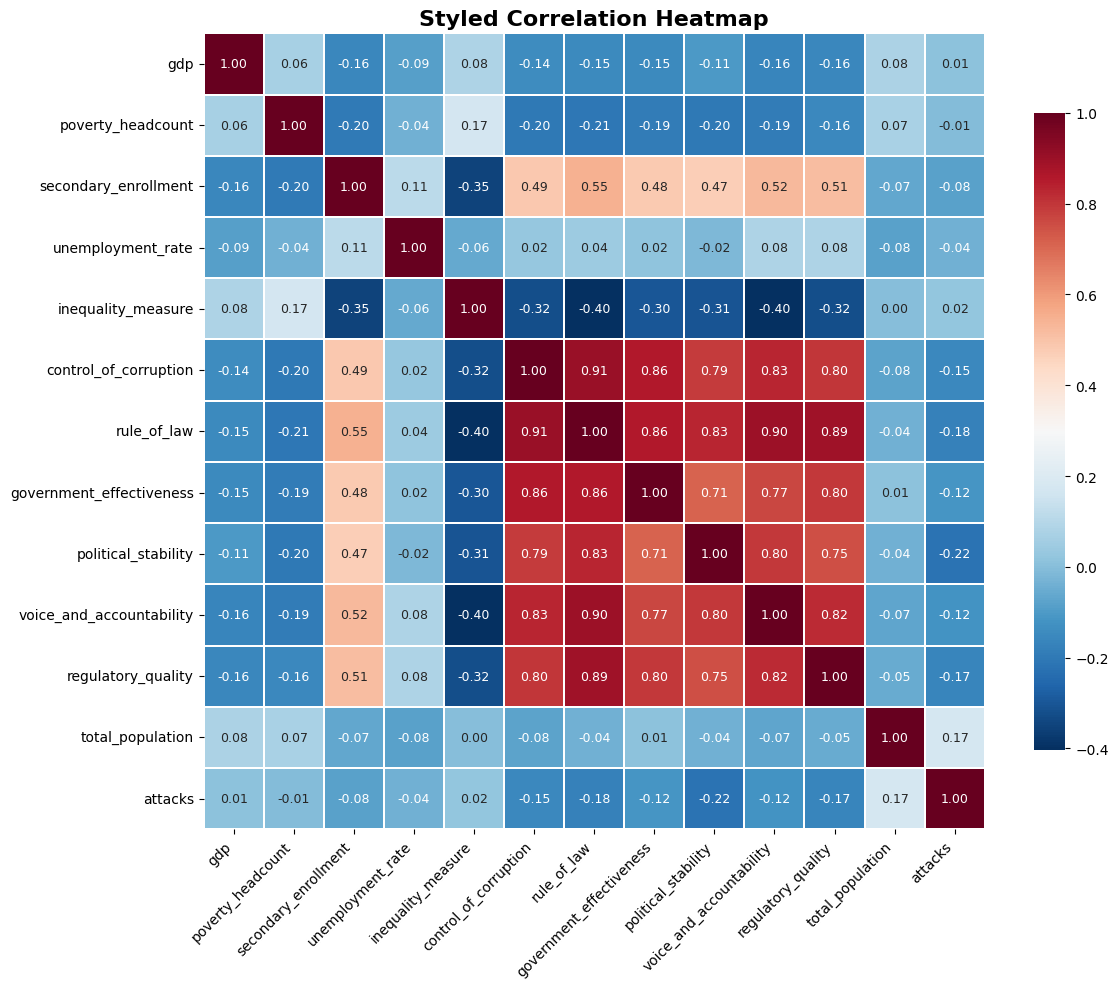

In [88]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9}
)

plt.title("Styled Correlation Heatmap", fontsize=16, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

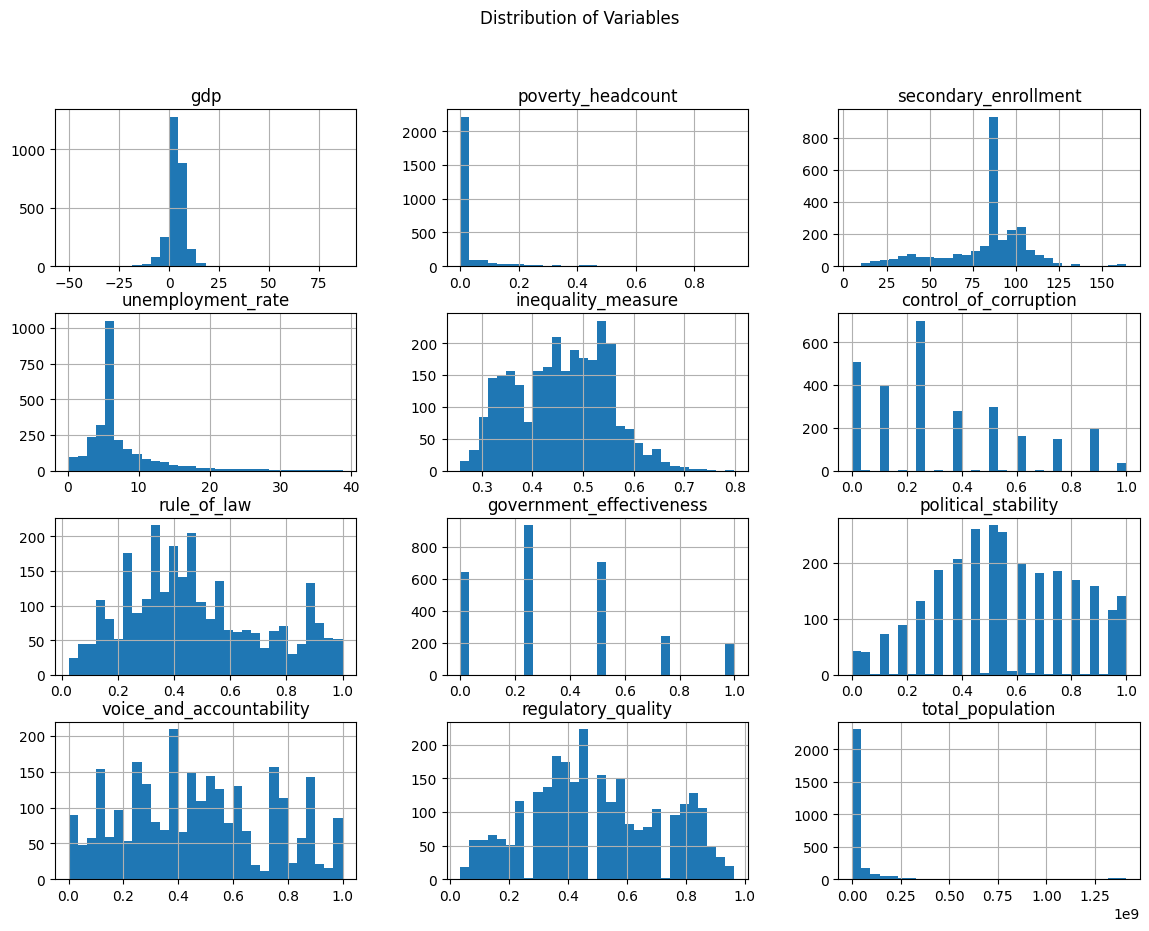

In [89]:
import matplotlib.pyplot as plt

df_model[independent_vars].hist(figsize=(14,10), bins=30)
plt.suptitle("Distribution of Variables")
plt.show()

In [103]:
import numpy as np

cols_to_impute = ['poverty_headcount', 'control_of_corruption', 
                  'government_effectiveness', 'political_stability', 
                  'voice_and_accountability']

# Impute with median
for col in cols_to_impute:
    df_model[col] = df_model[col].replace(0, np.nan)
    df_model[col].fillna(df_model[col].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_16592\1954860315.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(df_model[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16592\1954860315.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [104]:
import numpy as np

df_model["log_gdp"] = np.log1p(df_model["gdp"])
df_model["log_population"] = np.log1p(df_model["total_population"])
df_model["log_unemployment"] = np.log1p(df_model["unemployment_rate"])
df_model["log_poverty"] = np.sqrt(df_model["poverty_headcount"])
df_model["log_attack"] = np.log1p(df_model["attacks"]+1)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


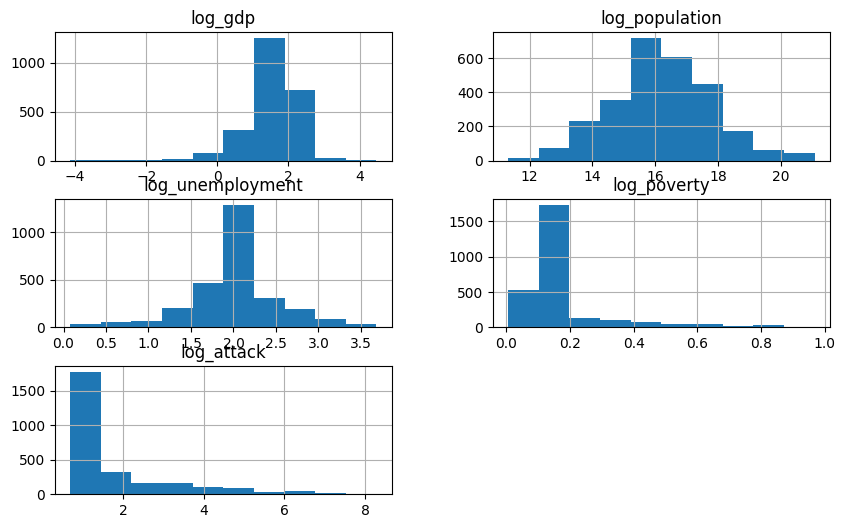

In [105]:
df_model[["log_gdp", "log_population", "log_unemployment", "log_poverty","log_attack"]].hist(figsize=(10,6))
plt.show()

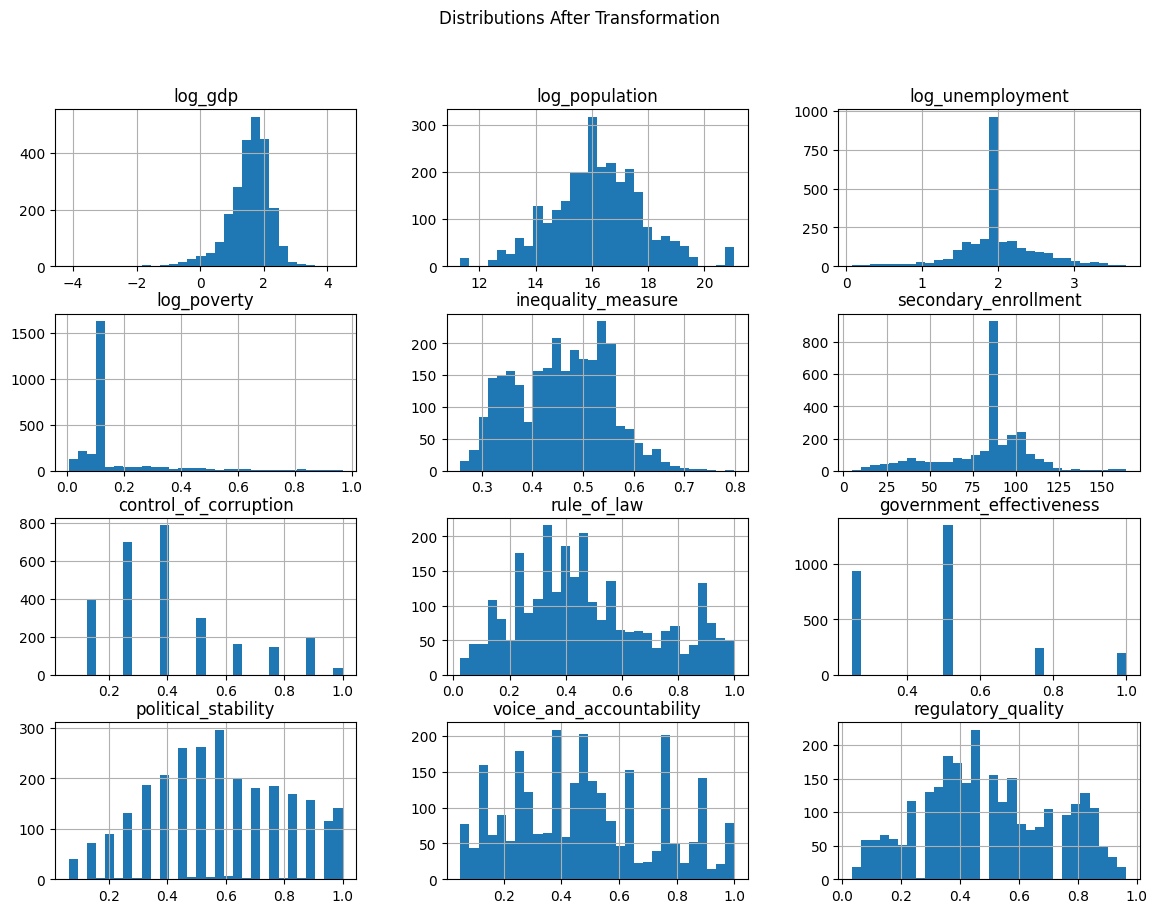

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select transformed + remaining variables
check_vars = [
    "log_gdp",
    "log_population",
    "log_unemployment",
    "log_poverty",
    "inequality_measure",
    "secondary_enrollment",
    "control_of_corruption",
    "rule_of_law",
    "government_effectiveness",
    "political_stability",
    "voice_and_accountability",
    "regulatory_quality"
]

df_model[check_vars].hist(figsize=(14,10), bins=30)
plt.suptitle("Distributions After Transformation")
plt.show()


In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df_model[check_vars]

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif.sort_values("VIF", ascending=False))

MissingDataError: exog contains inf or nans

C:\Users\DELL\AppData\Local\Temp\ipykernel_16592\1954860315.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(df_model[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_16592\1954860315.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

In [ ]:
(df_model == 0).sum()

country                        0
year                           0
gdp                            0
total_population               0
poverty_headcount              0
secondary_enrollment           0
unemployment_rate              0
inequality_measure             0
control_of_corruption          0
rule_of_law                    0
government_effectiveness       0
political_stability            0
voice_and_accountability       0
regulatory_quality             0
attacks                     1293
log_gdp                        0
log_population                 0
log_unemployment               0
log_poverty                   44
log_attack                     0
dtype: int64